In [1]:
import datetime

import numpy as np
import pandas as pd
import geopandas as gpd
import movingpandas as mpd
import shapely as shp
import hvplot.pandas
import matplotlib.pyplot as plt
import matplotlib.colors
import folium
import shapely



In [2]:
mmsi_a = 265550210
mmsi_b = 265410000

color_a = (0, 0.3, 0.3)
color_b = (0.3, 0, 0.3)
t_0 = datetime.datetime(2017, 7, 5, 19, 0, 0)
t_1 = datetime.datetime(2017, 7, 5, 19, 13, 55)

In [3]:
ais_gdf = gpd.read_file('../data/ais.gpkg')
ais_gdf["t"] = pd.to_datetime(ais_gdf["Timestamp"], format="%d/%m/%Y %H:%M:%S")
ais_gdf['t_min_t_0'] = (ais_gdf["t"] - t_0).dt.total_seconds()

ais_gdf = ais_gdf.to_crs('EPSG:32632')

In [4]:
ais_gdf = ais_gdf[
    np.logical_and.reduce([
        ais_gdf['MMSI'].isin([mmsi_a, mmsi_b]),
        ais_gdf['t'] >= t_0,
        ais_gdf['t'] < t_1
    ])
]


In [5]:
ais_gdf['traj_id'] = ais_gdf['MMSI']
ais_gdf['obj_id'] = ais_gdf['MMSI']
traj_collection = mpd.TrajectoryCollection(
    ais_gdf.set_index('t'), 
    traj_id_col="traj_id", 
    obj_id_col="obj_id",
    min_length=100
)
traj_collection.add_speed(overwrite=True, units=('m', 's'))
traj_collection.add_direction(overwrite=True)


TrajectoryCollection with 2 trajectories

In [6]:
traj_collection_wgs84 = mpd.TrajectoryCollection(
    ais_gdf.to_crs('EPSG:4326').set_index('t'), 
    traj_id_col="traj_id", 
    obj_id_col="obj_id",
    min_length=100
)


In [7]:
# show trajectories with number of seconds since t_0
traj_collection_wgs84.hvplot(c='t_min_t_0', cmap='Blues')

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Path.I   :Path   [Longitude,Latitude]   (t_min_t_0)
   .Points.I :Points   [Longitude,Latitude]   (t_min_t_0,triangle_angle)

In [8]:

traj_a = traj_collection.get_trajectory(mmsi_a)
traj_b = traj_collection.get_trajectory(mmsi_b)


In [9]:
# we follow the implementation of postgis
# https://github.com/postgis/postgis/blob/9637dc369361ac118e1ad37da7a519dae9dfab5e/postgis/lwgeom_functions_temporal.c#L83
# gbox is the bounding box in x,y,z,m
# tmin = FP_MAX(gbox1.mmin, gbox2.mmin);
# tmax = FP_MIN(gbox1.mmax, gbox2.mmax);

t_min = max(traj_a.get_start_time(), traj_b.get_start_time())
t_max = min(traj_a.get_end_time(), traj_b.get_end_time())
t_min, t_max


# * Collect M values in common time range from inputs
# nmvals in postgis
t_ab = np.unique(np.sort(np.r_[traj_a.df.index, traj_b.df.index]))
t_ab_intervals = np.c_[t_ab[:-1], t_ab[1:]]
t_ab_intervals[:3]

array([['2017-07-05T19:00:01.000000000', '2017-07-05T19:00:04.000000000'],
       ['2017-07-05T19:00:04.000000000', '2017-07-05T19:00:05.000000000'],
       ['2017-07-05T19:00:05.000000000', '2017-07-05T19:00:07.000000000']],
      dtype='datetime64[ns]')

In [10]:
def segments_tcpa(
    p0: shapely.Point,
    p1: shapely.Point, 
    q0: shapely.Point, 
    q1: shapely.Point, 
    t0: datetime.datetime, 
    t1: datetime.datetime
):


    
    # convert to arrays (ignore z)
    p0 = np.asarray(p0.coords)
    p1 = np.asarray(p1.coords)
    q0 = np.asarray(q0.coords)
    q1 = np.asarray(q1.coords)
    
    # compute the following
    # pv; /* velocity of p, aka u */
    # qv; /* velocity of q, aka v */
    # dv; /* velocity difference */
    # w0; /* vector between first points *# 
    
    # pv = (p1 - p0);
    pv = p1 - p0
    
    # qv = (q1 - q0);
    qv = q1 - q0
    
    # dv = pv - qv
    dv = pv - qv
    

    dv2 = np.dot(dv, dv.T).item()

    if (dv2 == 0.0):
        # /* Distance is the same at any time, we pick the earliest */
        return t0
    
    # /* Distance at any given time, with t0 */
    # p0 - q0
    w0 = p0 - q0
    w0
    
    # t = -DOT(w0, dv) / dv2;
    assert dv2 != 0, "dv2 should not be 0"
    t = (-np.dot(w0, dv.T) / dv2).item()
    
    
    # converging
    if t > 1:
        t = 1
    elif t < 0.0:
        # diverging
        t = 0
    
    # Not sure why this is computed .... 
    # p0 += pv * t;
    # q0 += qv * t;
    p0 += pv * t 
    q0 += qv * t
    
    # p0 and q0 have now been updated to the position at the cpa
    p = shapely.Point(*p0) 
    q = shapely.Point(*q0)
    
    # We can now also compute tcpa
    # t = t0 + (t1 - t0) * t;
    t = t0 + (t1 - t0) * t

    return t
    

t0, t1 = interval = t_ab_intervals[200]


p0 = traj_a.interpolate_position_at(t0)
p1 = traj_a.interpolate_position_at(t1)
q0 = traj_b.interpolate_position_at(t0)
q1 = traj_b.interpolate_position_at(t1)

tcpa = segments_tcpa(p0=p0, p1=p1, q0=q0, q1=q1, t0=t0, t1=t1)
tcpa




numpy.datetime64('2017-07-05T19:12:29.000000000')

In [11]:

# def traj_tcpa(traj_a, traj_b, mindist = 1000):

# interval = t_ab_intervals[200]

mindist = 1000

mindist2 = np.finfo(np.double).max

for interval in t_ab_intervals:
    

    t0, t1 = interval

    # determine p0, p1, q0, q1

    # seg = ptarray_locate_along_linear(l1->points, t0, &p0, 0);
    # seg = ptarray_locate_along_linear(l1->points, t1, &p1, seg);
    # seg = ptarray_locate_along_linear(l2->points, t0, &q0, 0);
    # seg = ptarray_locate_along_linear(l2->points, t1, &q1, seg);
    
    p0 = traj_a.interpolate_position_at(t0)
    p1 = traj_a.interpolate_position_at(t1)
    q0 = traj_b.interpolate_position_at(t0)
    q1 = traj_b.interpolate_position_at(t1)

    # t = segments_tcpa(&p0, &p1, &q0, &q1, t0, t1);
    tcpa = segments_tcpa(p0=p0, p1=p1, q0=q0, q1=q1, t0=t0, t1=t1)
    
    # And the distance at tcpa
    # dist2 = (q0.x - p0.x) * (q0.x - p0.x) + (q0.y - p0.y) * (q0.y - p0.y) + (q0.z - p0.z) * (q0.z - p0.z);
    dqp = np.asarray((q0 - p0).coords)
    dist2 = np.dot(dqp, dqp.T).item()

    # TODO: distances are too big
    if (dist2 < mindist2):
        mindist2 = dist2
        mintime = tcpa

if (mindist is not None):
    mindist = np.sqrt(mindist2)
mintime



numpy.datetime64('2017-07-05T19:13:52.000000000')

<Axes: >

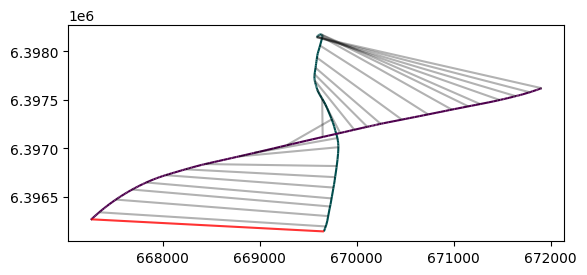

In [12]:
fig, ax = plt.subplots()
traj_a.plot(color=color_a, ax=ax)
traj_b.plot(color=color_b, ax=ax)


# show all the closest points of approaches between these two ships

for (t0, t1) in t_ab_intervals[::10]:
    tcpa = segments_tcpa(p0=p0, p1=p1, q0=q0, q1=q1, t0=t0, t1=t1)
    cpa_a = traj_a.interpolate_position_at(tcpa)
    cpa_b = traj_b.interpolate_position_at(tcpa)
    cpa_ab = shapely.LineString([cpa_a, cpa_b])
    gpd.GeoSeries([cpa_ab]).plot(color='k', alpha=0.3, ax=ax)


cpa_a = traj_a.interpolate_position_at(mintime)
cpa_b = traj_b.interpolate_position_at(mintime)
cpa_ab = shapely.LineString([cpa_a, cpa_b])
gpd.GeoSeries([cpa_ab]).plot(color='r', alpha=0.8, ax=ax)



In [13]:
import pyproj
geod = pyproj.Geod(ellps="WGS84")



In [14]:
row = traj_a.df.iloc[0]
row

Timestamp                            05/07/2017 19:00:05
MMSI                                           265550210
NavStatus                                  Unknown value
SOG                                                  0.0
COG                                                156.9
Name                                            TANKSKAR
ShipType                                          Tanker
geometry     POINT (669586.8317745987 6398147.291889774)
t_min_t_0                                            5.0
traj_id                                        265550210
obj_id                                         265550210
speed                                                0.0
direction                                            0.0
Name: 2017-07-05 19:00:05, dtype: object

In [15]:
lon, lat, az = geod.fwd(row['geometry'].x, row['geometry'].y, az=np.deg2rad(row['COG']), dist=1000)

In [16]:
def project(row, max_distance=1000):
    dist = [1000]
    lons = [row['geometry'].x for x in range(len(dist))]
    lats = [row['geometry'].y for y in range(len(dist))]
    az = [row['COG'] for cog in range(len(dist))]
    lons, lats, az = geod.fwd(lons=lons, lats=lats, az=az, dist=dist)
    
    points = [
        row['geometry']
    ] + [
        shapely.geometry.Point(lon, lat) for lon, lat in zip(lons, lats)
    ]
    geom = shapely.LineString(points)
    t_0 = row.index
    return geom


In [17]:
traj_a_projections = traj_a.df.apply(project, max_distance=2000, axis=1)
traj_b_projections = traj_b.df.apply(project, max_distance=2000, axis=1)

IndexError: index out of range

In [ ]:
fig, ax = plt.subplots()
traj_a_projections.plot(alpha=0.3, ax=ax, color=(0.8, 0.3, 0.8))
traj_b_projections.plot(alpha=0.3, ax=ax, color=(0.8, 0.8, 0.3))